In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Etat de Référence / Variables

In [39]:
D0 = 0 # initial quantity of theobromine in the dog's body (mg/kg)
S0 = 0 # initial severity of symptoms
M_choc = np.array([10, 50, 100]) # initial mass of the chocolate ingested (g)
c_type = np.array([0.009, 1.85, 9.75]) # quantity of theobromine per gram of chocolate (mg/g) [chocolate blanc, chocolat au lait, chocolat noir]
W = np.array([15, 40, 60])  # weight of the dog (kg) [petit, moyen, grand]
k_abs = 0.5 # absorption rate constant (1/h) (au hasard pour l'instant)
k_e = 0.040 # elimination rate constant (1/h)
f = k_abs/(k_abs + k_e) # fraction of theobromine absorbed into the bloodstream
p = 0.4 # taux d'activation de symptômes (1/h)
K_D = np.array([20, 45, 60, 150]) # concentration of theobromine at which symptoms appear (mg/kg) (seuils de sévérité des symptômes) [léthargie, vomissements, convulsions, décès]
n = 4 # Hill coefficient
mu = 0.026 # taux de récupération (1/h)
Q0 = f*c_type[0]*M_choc[0] # initial amount of theobromine in the gastrointestinal compartment (mg)

## Modèle

In [40]:
def model(t, y, k_abs, k_e, W, p, K_D, n, mu):

    Q, D, S1, S2, S3, S4 = y

    dQdt = -k_abs * Q
    dDdt = (k_abs / W) * Q - k_e * D

    dS1 = p*(D**n/(K_D[0]**n + D**n))*(1-S1) - mu*S1
    dS2 = p*(D**n/(K_D[1]**n + D**n))*(1-S2) - mu*S2
    dS3 = p*(D**n/(K_D[2]**n + D**n))*(1-S3) - mu*S3
    dS4 = p*(D**n/(K_D[3]**n + D**n))*(1-S4) - mu*S4

    return [dQdt, dDdt, dS1, dS2, dS3, dS4]

## Simulation

In [41]:
def run_sim(M, c, W):
    Q0 = f * c * M
    y0 = [Q0, 0, 0, 0, 0, 0]
    sol = solve_ivp(model, (0, 48), y0, args=(k_abs, k_e, W, p, K_D, n, mu), t_eval=np.arange(0, 48, 2))
    return sol

results = []

for w in W:
    for c in c_type:
        for M in M_choc:

            sol = run_sim(M, c, w)

            results.append({
                "W": w,
                "c": c,
                "M": M,
                "sol": sol,
                "Smax": np.max(sol.y[2:6]),
                "Dmax": np.max(sol.y[1])
            })

import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)

     W      c    M                                                sol  \
0   15  0.009   10  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
1   15  0.009   50  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
2   15  0.009  100  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
3   15  1.850   10  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
4   15  1.850   50  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
5   15  1.850  100  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
6   15  9.750   10  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
7   15  9.750   50  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
8   15  9.750  100  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
9   40  0.009   10  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
10  40  0.009   50  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
11  40  0.009  100  {'t': [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, ...   
12  40  1.850   10  {'t': [0, 2, 4, 6, 8, 10, 12, 1

In [42]:
for w in W:
    subset = [r for r in results if r["W"] == w]
    print(w, min(r["Smax"] for r in subset), max(r["Smax"] for r in subset))

15 7.487642486735484e-15 0.9322879802502713
40 1.4789120541674176e-16 0.6995573930152343
60 2.919567154032601e-17 0.2998640052696381


## Visualisation

### 1. Evolution temporelle

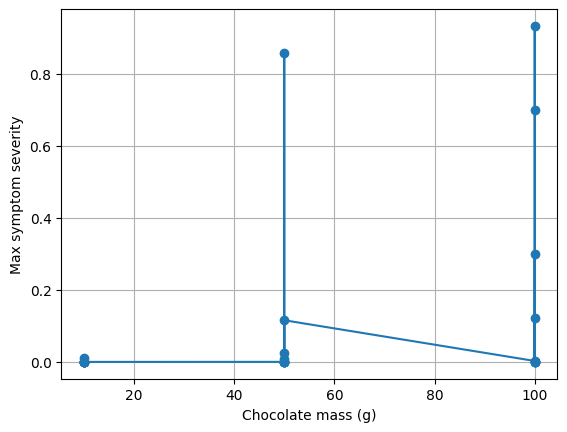

In [43]:
M_vals = np.array([r["M"] for r in results])
S_vals = np.array([r["Smax"] for r in results])

# tri obligatoire pour avoir une belle courbe
idx = np.argsort(M_vals)

plt.plot(M_vals[idx], S_vals[idx], marker="o")
plt.xlabel("Chocolate mass (g)")
plt.ylabel("Max symptom severity")
plt.grid()
plt.show()